In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [29]:
from tudatpy.interface import spice
from tudatpy.dynamics import environment_setup, parameters_setup, propagation_setup
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, estimation_analysis
from tudatpy.constants import GRAVITATIONAL_CONSTANT
from tudatpy.astro.frame_conversion import inertial_to_rsw_rotation_matrix
import matplotlib.gridspec as gridspec
from tudatpy.data.mpc import BatchMPC
from tudatpy.data.horizons import HorizonsQuery
from tudatpy.data.sbdb import SBDBquery
from tudatpy.estimation import observable_models, observations_setup, observations
from tudatpy import dynamics ## needed to get additional parameters to fit

# other useful modules
import numpy as np
import datetime
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from tudatpy.astro import time_representation
from tudatpy.astro.time_representation import DateTime
from astropy.table import Table
from tudatpy.astro import element_conversion    # for TU3 initial state

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates

# SPICE KERNELS
spice.load_standard_kernels()

# Defining some constants

In [70]:
# Target 1998 TU3 (66146)
# target_mpc_code = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
target_mpc_code = [1566, 66146, 66391, 437844]
# target_mpc_code = [1566, 66146]

observations_start = datetime.datetime(1980,1,1)
observations_end = datetime.datetime(2026, 1, 1)

# number of iterations for our estimation
# Change this depending on how long you want the convergence to run
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 2 month time buffer used to avoid interpolation errors:
time_buffer = 2 * 31 * 86400.0

# Define the frame origin and orientation
# This is useful for the large functions at the end
# However, I still define the frame orientation before then for my bodies
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

include_minor_bodies = False

In [71]:
#target_sbdb = SBDBquery(target_mpc_code)
#
#mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
#target_spkid = target_sbdb.codes_300_spkid  # the ID used by Tudat
#obj = target_sbdb.query["object"]
#
## The ID used by Tudat (biggest asteroids have shortname, but smaller don't)
#target_name = (
#    obj.get("shortname") or
#    obj.get("fullname") or
#    obj.get("des")
#)  
#
#print(f"SPK ID for {target_name} is: {target_spkid}")

# Retrieving the observations

In [72]:

mpc_codes = target_mpc_code  # the BatchMPC interface requires a list.
batch = BatchMPC()
batch.get_observations(mpc_codes)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)
print(batch.summary())

## Make sure wrapping is not an issue
batch.table["RA"] = (batch.table["RA"] + np.pi) % (2*np.pi) - np.pi


   Batch Summary:
1. Batch includes 4 minor planets:
   ['1566', '66146', '66391', '437844']
2. Batch includes 8200 observations, including 480 observations from space telescopes
3. The observations range from -548030822.4971857 to 808752696.4853065
   In seconds TDB since J2000: -548030822.4971857 to 808752696.4853065
   In Julian Days: 2445202.05005 to 2460905.562816
4. The batch contains observations from 239 observatories, including 2 space telescopes

None


In [73]:
epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")


# This samples the cartesian state at 500 points over the observation time:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print(f"Epoch Start (buffer): {DateTime.from_epoch(epoch_start_buffer)}")
print(f"Epoch End (buffer): {DateTime.from_epoch(epoch_end_buffer)}")
print()
print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Epoch Start (no buffer): -548030822.4971857
Epoch End (no buffer): 808752696.4853065
--------------------------------------------------
Epoch Start (no buffer): 1982-08-20 13:12:57.502814292907715
Epoch End (no buffer): 2025-08-18 01:31:36.485306501388550
--------------------------------------------------
Epoch Start (buffer): 1982-06-19 13:12:57.502814292907715
Epoch End (buffer): 2025-10-19 01:31:36.485306501388550

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE  163.0
1245  C57  TESS  317.0


# Set up the environment

In [74]:
larger_bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon", ## DIFF
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
]

# larger_bodies_to_create = [
#     "Sun",
#     "Mercury",
#     "Venus",
#     "Earth",
#     "Moon",
#     "Mars",
#     "Phobos",   # Mars
#     "Deimos",   # Mars
#     "Ceres",
#     "Vesta",
#     "Jupiter",
#     "Io",       # Jupiter
#     "Europa",   # Jupiter
#     "Ganymede", # Jupiter
#     "Callisto", # Jupiter
#     "Saturn",
#     "Titan",    # Saturn
#     "Rhea",     # Saturn
#     "Iapetus",  # Saturn
#     "Dione",    # Saturn
#     "Tethys",
#     "Enceladus",
#     "Mimas",
#     "Uranus",
#     "Neptune",
# ]

if include_minor_bodies:
    ## Ignore this for now
    smaller_bodies = {
        "Ceres": [1, 62.10], 
        "Pallas": [2, 13.73],
        "Juno": [3, 1.61],
        "Vesta": [4, 17.38],
        "Hebe": [6, 0.89],
        "Iris": [7, 0.73],
        "Flora": [8, 0.27],
        "Metis": [9, 0.44],
        "Hygiea": [10, 5.97],
        "Irene": [14, 0.25],
        "Eunomia": [15, 1.88],
        "Psyche": [16, 1.65],
        "Fortuna": [19, 0.42],
        "Thalia": [23, 0.15],
        "Amphitrite": [29, 0.98],
        "Daphne": [41, 0.56],
        "Europa": [52, 1.48],
        "Bamberga": [324, 0.71],
        "Davida": [511, 1.14],
        "Herculina": [532, 0.66],
        "Interamnia": [704, 2.65]
    }

In [75]:
# Many of the asteroids do not exist in the SPICE kernel
# Therefore I'm now adding them by downloading them in SPK files from the JPL Horizon website
# Then I will extract them with load_kernel

# ---------------------------------------------------------
# The path to the folder where the .bsp files are located
#kernel_directory = "/home/emmabob/Bachelor_Project/asteroid_kernels/" 
kernel_directory = "/home/balbinot/Bachelor_Project_Emma/asteroid_kernels/" 
print("Number of kernels:", spice.get_total_count_of_kernels_loaded())

if include_minor_bodies:
    # Loop through the dictionary and load the corresponding .bsp file
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
        
        # Calculate the NAIF ID from the data list
        # E.g. Juno has 20000003 (ID: 3)
        ast_id = data[0]
        naif_id = 20000000 + ast_id
        
        # Then extract the ephemeris for each asteroid
        kernel_path = os.path.join(kernel_directory, f"{naif_id}.bsp")
        if os.path.exists(kernel_path):
            spice.load_kernel(kernel_path)
            print(f"{i}.Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
        else:
            print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")

Number of kernels: 13


In [76]:
asteroid_id_list = [str(i_ast) for i_ast in target_mpc_code]

smaller_bodies_list = []
if include_minor_bodies:
    smaller_bodies_list = list(smaller_bodies.keys())

bodies_to_create = larger_bodies_to_create + smaller_bodies_list + asteroid_id_list
bodies_to_propagate = asteroid_id_list     # I only propagate TU3, I pull the other values from pre-existing ephemeris

# ----------------------------
# Create bodies in simulation.
# Pull on the data already known for the larger bodies
body_settings = environment_setup.get_default_body_settings(
    bodies = larger_bodies_to_create, 
    base_frame_origin = 'SSB',                   # Correct as initial conditions from JPL are in SSB
    base_frame_orientation = 'J2000')       # Intiial conditions from JPL are in J2000


# Add a buffer time
buffer_time = 5 * constants.JULIAN_DAY

if include_minor_bodies:
    # A for loop to extract and add settings for the 21 massive asteroids from JPL Horizon
    for i, (name, data) in enumerate(smaller_bodies.items(), start=1):
    
        # Extract asteroid properties
        ast_id = data[0]
        ast_mu = data[1] * 1e9  # Convert km^3/s^2 to m^3/s^2 (SI-units); reduced mass
    
        # Calculate the SPICE NAIF ID (2000000 + minor planet number) again
        naif_id = 20000000 + ast_id
    
        try:
            
            # To fix Tudat finding the data:
            naif_id_str = str(2000000 + ast_id)
    
            # Instead try extracting the ephemeris from SPICE (w. direct_spice) 
            DIRECT_ephemeris_settings_ast = environment_setup.ephemeris.direct_spice(
                frame_origin = 'SSB',                    # The SPK files were w.r.t the Sun
                frame_orientation = 'J2000',        # tells Tudat the asteroids' coordinates are wrt ECLIPJ2000 
                body_name_to_use = naif_id_str)
    
            # Create empty slots, then insert the asteroids
            body_settings.add_empty_settings(name)
            # Assign ephemeris
            body_settings.get(name).ephemeris_settings = DIRECT_ephemeris_settings_ast
    
            # Assign gravity field (w. the central function that manually adds the mu)
            body_settings.get(name).gravity_field_settings = (
                environment_setup.gravity_field.central(ast_mu)
            )
    
            print(f" {i}. Successfully configured {name} (ID: {ast_id} / NAIF: {naif_id})")
    
        except Exception as e:
            print(f"Could not fetch data for {name}: {e}")


## NOTE EB: I removed this without any impact on the rest of the code
## NOTE: body_settings does not include the members in target_mpc_list
# Manually add empty settings for 9 asteroids
#for name in asteroid_id_list:
#    body_settings.add_empty_settings(name)


In [77]:
# Define the solar quadrupole moment
# See Book by Montenbruck and Gill, pg 57-58 for the conversion/ equations
# To understand function see: https://py.api.tudat.space/en/latest/dynamics/environment_setup/gravity_field.html#tudatpy.dynamics.environment_setup.gravity_field.spherical_harmonic
# For the Sun's gravitational potential, Sn0 is zero by definition

J_2 = 2.2 * 10**(-7)
norm_C_20 = - J_2 / np.sqrt(5)

norm_cosine_coeffs = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [norm_C_20, 0.0, 0.0]
])

norm_sine_coeffs = np.array([
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0]
])

# Technically I've defined this below as well
mu_Sun = 1.327124400420322e+20
radius_Sun = 695.99 * 10**6         # ± 0.07 * 10**6 m

body_settings.get("Sun").gravity_field_settings = (
    environment_setup.gravity_field.spherical_harmonic(
        gravitational_parameter = mu_Sun,
        reference_radius = radius_Sun,
        normalized_cosine_coefficients = norm_cosine_coeffs,
        normalized_sine_coefficients = norm_sine_coeffs,
        # Ensure Tudat knows that the values are defined in the Sun's fixed frame
        # The International Astronomical Union (IAU) defines standard body-fixed frames for well-known bodies
        associated_reference_frame = "IAU_Sun"      # Ensures that the buldge rotates with the body
    )
)

bodies = environment_setup.create_system_of_bodies(body_settings) ## Define this here too since observations need it?
bodies_to_propagate = batch.MPC_objects
central_bodies = ["SSB"] * len(batch.MPC_objects)

In [78]:
# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None,
                                        apply_star_catalog_debias=True, apply_weights_VFCC17=True,)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

/home/emmabob/Bachelor_Project/tudat-dev/.pixi/envs/default/lib/python3.14/site-packages/tudatpy/data/mpc/mpc.py:140: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  bias_dataframe[["aa", "bb", "cc", "dd"]] = unknown_columns
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function single_observation_set is deprecated. Use create_single_observation_set instead
Function s

In [79]:
initial_guess_list = []

for i_horizon in asteroid_id_list:
    print(i_horizon)
    obj = HorizonsQuery(
        query_id=i_horizon,
        location="@0",
        epoch_list=[epoch_start_buffer],
    )

    initial_guess = obj.cartesian(frame_orientation='J2000',
                aberations='geometric')

    initial_guess = initial_guess[0][1:]    # unpack and remvoe the first component (that is time)
    initial_guess_list.append(initial_guess)

# To make the initial guess into (N*6,) instead of (N, 6) (where N is the amount of asteroid estimated for)
# This makes the initial guess into one long array
initial_guess = np.concatenate(initial_guess_list)


1566
66146
66391
437844


In [80]:
# initial_guess - initial_guess_spice

In [81]:
times_get_eph = np.linspace(epoch_start_nobuffer.to_epoch(), epoch_end_nobuffer.to_epoch(), 500)
epoch_start_buffer = epoch_start_nobuffer.to_epoch() - time_buffer
epoch_end_buffer = epoch_end_nobuffer.to_epoch() + time_buffer

print("The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):")
print(epoch_start_buffer, initial_guess)

The initial state for 1998-TU3 (20066146) in SPICE at epoch_start (w a buffer):
-553387622.4971857 [ 1.57866210e+11 -1.76481530e+11 -1.51945128e+11  3.51440446e+03
  9.97482986e+03  2.84844722e+03 -4.88769985e+10 -3.73850371e+10
 -1.03392864e+10  2.58668790e+04 -4.40153307e+04 -2.05708461e+04
 -1.90072386e+10 -1.53019814e+11 -2.59627587e+10  1.40915323e+04
  2.42017331e+03  9.98493111e+03  7.51919830e+10 -8.10302224e+10
 -3.85794341e+10  5.28406155e+03  2.78697785e+04  1.20543102e+04]


In [82]:
# For TU3 the value of A2 is computed 

avg_a_TU3_greenberg = -5.60 * 10**(-4)                       # AU / Myr 
avg_a_TU3_calc = -5.60 * 10**(-4) / (10**6 * 365)            # AU / days
uncertain_avg_a_TU3_greenberg = 3.9 * 10**(-4)               # AU / Mry
uncertain_avg_a_TU3_calc = 3.9 * 10**(-4) / (10**6 * 365)    # AU / days

a_TU3_calc = 0.7875484323220899 # AU
e_TU3_calc = 0.4836694929440215 # unitless
n_TU3_calc = 1.410224212386279  # degrees/ days (remember that angles are unitless in unit conversion)

A_2_TU3_AUdays2 = avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2
A_2_TU3_uncertainty_AUdays2 = uncertain_avg_a_TU3_calc * (n_TU3_calc * (a_TU3_calc**2) * (1 - (e_TU3_calc**2))) / 2

print(f"The Yarkovksy parameter for TU3: {A_2_TU3_AUdays2} AU / days^2")
print(A_2_TU3_uncertainty_AUdays2)

# Units from AU/days2 to m/s2
A_2_TU3_ms2 = A_2_TU3_AUdays2 * 149597870691 / ((24 * 3600)**2)
print(A_2_TU3_ms2)

The Yarkovksy parameter for TU3: -5.14011492352202e-13 AU / days^2
3.579722893167121e-13
-1.030079528444796e-11


In [83]:
# The planets
acceleration_planets_LVL3 = {
    "Sun": [
        #propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True), # General Relativity
        #propagation_setup.acceleration.yarkovsky(A_2_TU3_ms2), 
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Moon": [propagation_setup.acceleration.point_mass_gravity()], ## THE FREEKING MOON
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}


# # LVL 3 from Tudat example
# acceleration_planets_LVL3 = {
#     "Sun": [
#         # propagation_setup.acceleration.point_mass_gravity(),
#         propagation_setup.acceleration.spherical_harmonic_gravity(2, 0) ,
#         propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
#     ],
#     "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
#     "Venus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Earth": [
#         propagation_setup.acceleration.spherical_harmonic_gravity(2, 2),
#     ],
#     "Moon": [propagation_setup.acceleration.point_mass_gravity()],

#     "Mars": [propagation_setup.acceleration.point_mass_gravity()],
#     "Phobos": [propagation_setup.acceleration.point_mass_gravity()],
#     "Deimos": [propagation_setup.acceleration.point_mass_gravity()],

#     "Ceres": [propagation_setup.acceleration.point_mass_gravity()],
#     "Vesta": [propagation_setup.acceleration.point_mass_gravity()],
#     "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
#     "Io": [propagation_setup.acceleration.point_mass_gravity()],
#     "Europa": [propagation_setup.acceleration.point_mass_gravity()],
#     "Ganymede": [propagation_setup.acceleration.point_mass_gravity()],
#     "Callisto": [propagation_setup.acceleration.point_mass_gravity()],

#     "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
#     "Titan": [propagation_setup.acceleration.point_mass_gravity()],
#     "Rhea": [propagation_setup.acceleration.point_mass_gravity()],
#     "Iapetus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Dione": [propagation_setup.acceleration.point_mass_gravity()],
#     "Tethys": [propagation_setup.acceleration.point_mass_gravity()],
#     "Enceladus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Mimas": [propagation_setup.acceleration.point_mass_gravity()],
#     "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
#     "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
# }


if include_minor_bodies:
    accelerations_asteroids = {
        
        asteroid_name_21_index: [
            propagation_setup.acceleration.point_mass_gravity()
        ]
        for asteroid_name_21_index in smaller_bodies_list
    }
    
    
    # Merge dictionaries
    accelerations_merged_LVL3 = (
        acceleration_planets_LVL3 |
        accelerations_asteroids
    )
    
else:
    accelerations_merged_LVL3 = acceleration_planets_LVL3
    

# For testing remove asteroids since estimar runs much faster like this
#accelerations_merged_LVL3 = acceleration_planets_LVL3

# Finally, define the acceleration for TU3
# Because only TU3 is propagated
acceleration_dict3 = {b: accelerations_merged_LVL3 for b in bodies_to_propagate}


In [84]:
acceleration_dict3

{'1566': {'Sun': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.SphericalHarmonicAccelerationSettings at 0x7d674518cc30>,
  'Mercury': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d66feec7530>],
  'Venus': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d674518e6b0>],
  'Earth': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d6744dfceb0>],
  'Moon': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d6744dffbb0>],
  'Mars': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d6744dfddb0>],
  'Jupiter': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d6744dfde30>],
  'Saturn': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x7d6744dfe7b0>],
  'Uranus': [<tudatpy.kernel.dynamics.propagation_setup.acceleration.AccelerationSettings at 0x

In [85]:
# Thus, the environment becomes:
# In other of my files this is body_system
# However to be compatible with Tudat example, here it's called bodies
#bodies = environment_setup.create_system_of_bodies(body_settings)

In [86]:
# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)
# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

In [87]:
# Create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_dict3, bodies_to_propagate, central_bodies
)

In [88]:
print(central_bodies, acceleration_models, bodies_to_propagate)

['SSB', 'SSB', 'SSB', 'SSB'] {'66146': {'Venus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feeda5f0>], 'Uranus': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed8030>], 'Saturn': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed8e70>], 'Sun': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed8630>, <tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed87b0>], 'Mercury': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed8c70>], 'Moon': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed9070>], 'Mars': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed9b70>], 'Jupiter': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed8570>], 'Neptune': [<tudatpy.kernel.dynamics.propagation.AccelerationModel object at 0x7d66feed99b0>], 'Earth': [<tudatpy.kernel.dynamics.pr

In [89]:
# Create propagation settings
propagator_settings = propagation_setup.propagator.translational(
    central_bodies=central_bodies,
    acceleration_models=acceleration_models,
    bodies_to_integrate=bodies_to_propagate,
    initial_states=initial_guess,
    initial_time=epoch_start_buffer,
    integrator_settings=integrator_settings,
    termination_settings=termination_condition,
)

In [90]:
# Initial state
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

## J2 and Beta
parameter_settings.append(dynamics.parameters_setup.spherical_harmonics_c_coefficients_block("Sun", [(2,0)])) ##Indicate the indices of the free parameters in your C matrix for SPERICAL HARMONICS
parameter_settings.append(dynamics.parameters_setup.ppn_parameter_beta())

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

Warning when creating estimated parameters. The parameters will be ordered such that all parameters (excluding initial states) defined by a single variable will be stored before those represented by a list of variables. The parameter order will be different than those in your parameter settings. It is recommended that you check the parameter order by calling the print_parameter_names(Python)/printEstimatableParameterEntries(C++) function


In [91]:
# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times = observation_collection,
    convergence_checker = estimation_analysis.estimation_convergence_checker(
        maximum_iterations = number_of_pod_iterations,
    ),
)

# to_tudat() applies weights to a set of observations between an observatory and the target.
# the method below tells tudat to use the weights applied to these sets.
# This step is required when setting weights through the BatchMPC class.
if True:
    pod_input.set_weights_from_observation_collection()
    
# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)


# we store the following outputs for plotting and analysis.
#return pod_output, batch_temp, observations, estimator

setWeightsFromObservationCollection is deprecated: the weightsMatrixDiagonals_ vector is now by default defined by the weights stored in the ObservationCollection object. (see https://docs.tudat.space/en/latest/user-guide/state-estimation/observation-simulation/observation-collection-manipulation/modifying-collections.html#setting-weights).
Warning when performing least squares, condition number is 1.38089e+10
Warning when performing least squares, condition number is 1.41167e+10
Warning when performing least squares, condition number is 1.4117e+10
Warning when performing least squares, condition number is 1.4117e+10
Warning when performing least squares, condition number is 1.4117e+10
Warning when performing least squares, condition number is 1.4117e+10


Calculating residuals and partials 15440
Current residual: 0.000233769
Parameter update     240522      422586      148986  -0.0496025   0.0466566   0.0522368      164315     -208689     -107812    0.134651   0.0834288   0.0376826      512822     56070.7      354264   0.0304237    0.174654   0.0163714      341809  1.7984e+06      707109   -0.438486    0.442756    0.209972   0.0034368 2.32744e-06
Calculating residuals and partials 15440
Current residual: 4.56761e-06
Parameter update    -1046.39     -1620.87     -946.724 -5.77637e-05 -0.000119408 -6.01598e-05     -48615.2        88506      43701.2   -0.0486561   -0.0409407  -0.00899645      130.834      859.815       171.25  0.000136533  0.000526406  0.000173418     -9673.74       -39433     -22676.6   0.00669586  -0.00947025  -0.00438383  -0.00145397 -5.94683e-09
Calculating residuals and partials 15440
Current residual: 4.54918e-06
Parameter update    0.152342    0.0374425   -0.0364775  1.32332e-08 -1.67999e-08 -1.20158e-08     0.32267

In [92]:
## Get best-fit states at the same times as ephemeris of Horizons etc
state_estimates = {}
for asteroid_id in target_mpc_code:
    state_estimates[asteroid_id] = np.array(
        [
            bodies.get(str(asteroid_id)).ephemeris.cartesian_state(timee) for timee in times_get_eph
        ]
    )

In [93]:
#residual_history.shape (2*N, number_iterations)
#residual_history format is [RA_0, Dec_0, RA_1, Dec_1, ..., RA_N, Dec_N) where N is the number of observations
residual_history = pod_output.residual_history
residual_times = np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000

In [94]:
residual_times[::2]

array([2015.47816963, 2015.47817571, 2015.47818398, ..., 2018.42693678,
       2018.4269653 , 2018.42699347], shape=(7720,))

In [95]:
RA_residual_0 = residual_history[::2, 0] ## 0th iteration
Dec_residual_0 = residual_history[1::2, 0] ## 0th iteration
RA_residual_final = residual_history[::2, -1] ## final iteration
Dec_residual_final = residual_history[1::2, -1] ## final iteration

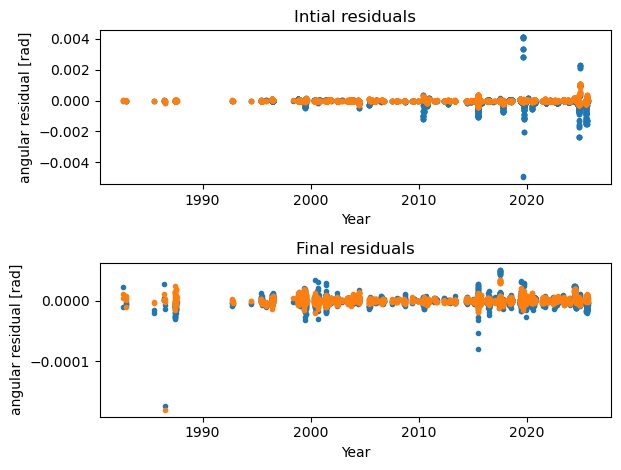

In [96]:
subplot(211)
plot(residual_times[::2], RA_residual_0, '.', label='RA')
plot(residual_times[1::2], Dec_residual_0, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Intial residuals')

subplot(212)
plot(residual_times[::2], RA_residual_final, '.', label='RA')
plot(residual_times[1::2], Dec_residual_final, '.', label='RA')
xlabel('Year')
ylabel("angular residual [rad]")
title('Final residuals')
     
tight_layout()

In [97]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[0]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

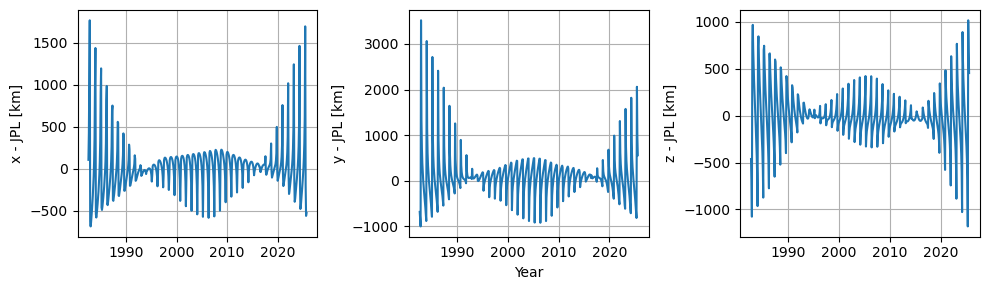

In [98]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[0]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [99]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[1]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

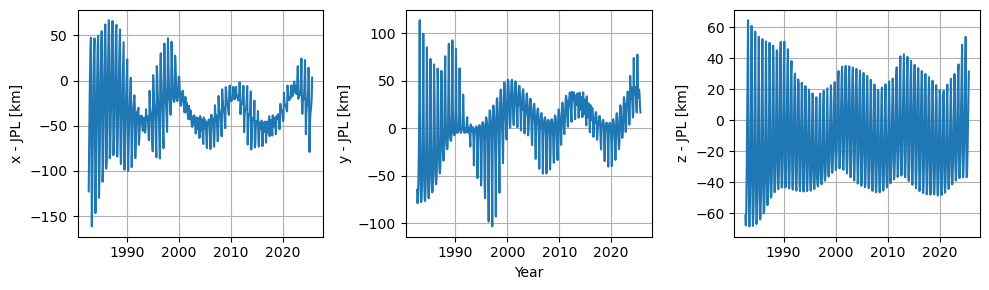

In [100]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[1]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [101]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[2]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

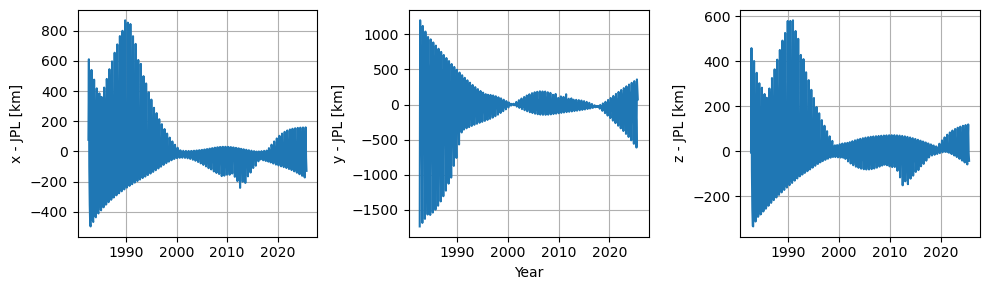

In [102]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[2]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

In [103]:
horizons_query = HorizonsQuery(
            query_id=f"{target_mpc_code[3]};",
            location=f"500@{global_frame_origin}",
            epoch_list=list(times_get_eph),
            extended_query=True,
        )

reference_states = horizons_query.cartesian(
            frame_orientation=global_frame_orientation,
            aberations='geometric'
        )[:, 1:]

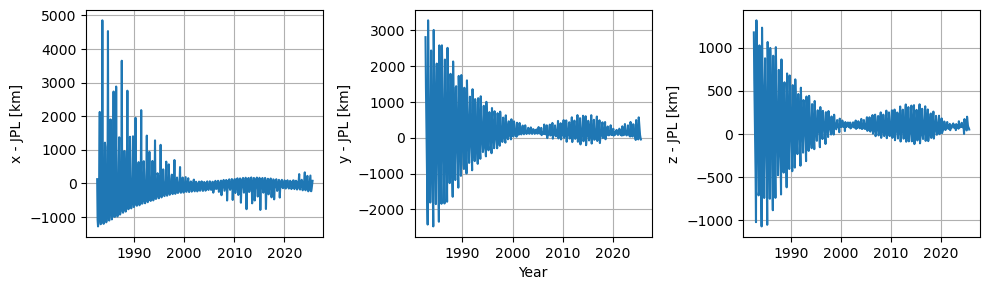

In [104]:
times_plot = times_get_eph / (86400 * 365.25) + 2000  # approximate for plot ticks

error_to_reference = (reference_states - np.array(state_estimates[target_mpc_code[3]] )) / 1000

figure(figsize=(10,3))
axs = [subplot(131), subplot(132), subplot(133)]
axs[0].plot(times_plot, error_to_reference[:, 0])
axs[0].set_ylabel('x - JPL [km]')
axs[0].grid()

axs[1].plot(times_plot, error_to_reference[:, 1])
axs[1].set_ylabel('y - JPL [km]')
axs[1].set_xlabel('Year')
axs[1].grid()

axs[2].plot(times_plot, error_to_reference[:, 2])
axs[2].set_ylabel('z - JPL [km]')
axs[2].grid()

tight_layout()

Text(0, 0.5, 'y [km]')

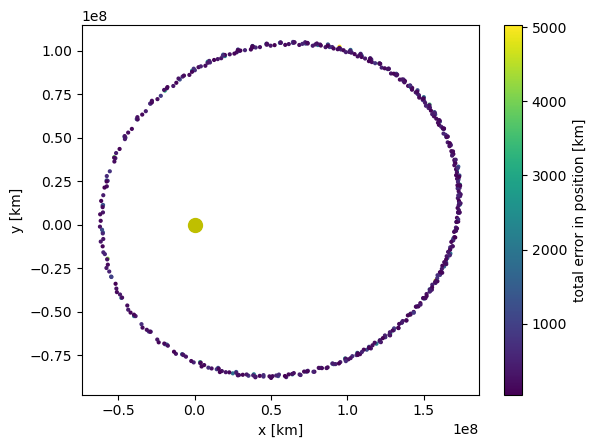

In [105]:
ee = state_estimates[target_mpc_code[1]]

scatter(ee[:,0]/1000, ee[:,1]/1000, c=np.linalg.norm(error_to_reference[:,], axis=1), s=4)
cb = colorbar()
cb.set_label('total error in position [km]')
plot(0, 0, 'yo', ms=10)
xlabel('x [km]')
ylabel('y [km]')

In [106]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

correlations = covariance_output.correlations

Calculating residuals and partials 15440


In [107]:
# Create a function to generate the axes of the covariance matrix

def build_estimated_param_names(mpc_target_asteroid):
    state_block = ["x", "y", "z", "vx", "vy", "vz"]

    estimated_param_names = []

    # repeat state block for each asteroid
    for _ in mpc_target_asteroid:
        estimated_param_names.extend(state_block)

    # add global parameters (only once)
    estimated_param_names += ["J2", "Beta-1"]

    return estimated_param_names


estimated_param_names = build_estimated_param_names(target_mpc_code)

print(estimated_param_names)

['x', 'y', 'z', 'vx', 'vy', 'vz', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'J2', 'Beta-1']


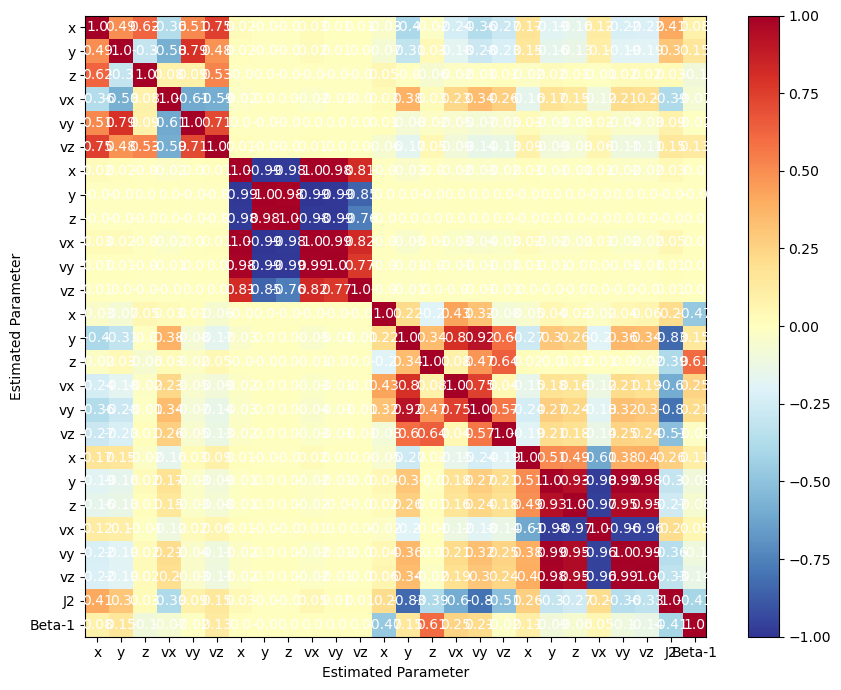

In [108]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

#fig.suptitle(f"Correlations for estimated parameters for {target_name}")

fig.set_tight_layout(True)

In [109]:
print(len(correlations))
print(correlations.size)
# print(correlations)
print(covariance_output.formal_errors)
# print(covariance_output.weighted_design_matrix)

26
676
[2.11461912e+04 2.46424361e+04 2.52562461e+04 8.55115676e-04
 1.25400498e-03 9.76078598e-04 2.64412918e+04 4.26930290e+04
 1.92530280e+04 2.55475994e-02 1.78290527e-02 8.67924477e-03
 7.41810611e+03 6.15310034e+03 8.57427327e+03 1.51786069e-03
 4.01785790e-03 1.81950789e-03 1.01051372e+04 4.06315393e+04
 2.19068226e+04 8.13941554e-03 1.05971582e-02 5.06505403e-03
 1.02614349e-02 3.59019281e-07]


In [42]:
1 / ((0.1 / (3600))**2)

1295999999.9999998

### Manually adding stellar occultations